In [2]:
import torch
import matplotlib.pyplot as plt
import pickle
import gzip
import seaborn as sns
from adjustText import adjust_text


if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

torch.no_grad().__enter__()

In [5]:
with gzip.open("/home/vast/target_dir/relevance-integrations/jobs/src.evd.attention_patterns.summarizeattentionpatterns/cff49811a1fab247048b8061b333a49078c5d290a3dcfa3e9c7bb35f709aa990/dataframes/attention.pkl.gz", "rb") as fp:
    data = pickle.load(fp)    
    
data_qid = data.groupby(["layer", "head", "rel", "qid"]).mean(numeric_only=True).reset_index()
data_qid.head()


,layer,head,rel,qid,q2d,d2q
0,0,0,non_relevant,1,0.047599,0.005177
1,0,0,non_relevant,10,0.031634,0.007934
2,0,0,non_relevant,1002,0.025717,0.004125
3,0,0,non_relevant,10034,0.012271,0.007301
4,0,0,non_relevant,10039,0.014263,0.005162


In [6]:
with gzip.open("/home/vast/target_dir/relevance-integrations/jobs/src.evd.attention_patterns.summarizeattentionpatterns/cff49811a1fab247048b8061b333a49078c5d290a3dcfa3e9c7bb35f709aa990/dataframes/attention_duplicate_token.pkl.gz", "rb") as fp:
    data_duplicate = pickle.load(fp)    

data_duplicate.rename(columns={"q2d": "dup_q2d", "d2q": "dup_d2q"}, inplace=True)
data_duplicate_qid = data_duplicate.groupby(["layer", "head", "rel", "qid"]).mean(numeric_only=True).reset_index()
print(data_duplicate_qid.head())

   layer  head           rel    qid   dup_q2d   dup_d2q
0      0     0  non_relevant      1  0.182991  1.940774
1      0     0  non_relevant     10  0.265305  1.101647
2      0     0  non_relevant   1002  0.234697  2.464028
3      0     0  non_relevant  10034  0.111965  0.621883
4      0     0  non_relevant  10039  0.072579  0.592421


In [7]:
with gzip.open("/home/vast/target_dir/relevance-integrations/jobs/src.evd.attention_patterns.summarizeattentionpatterns/cff49811a1fab247048b8061b333a49078c5d290a3dcfa3e9c7bb35f709aa990/dataframes/attention_entropy.pkl.gz", "rb") as fp:
    data_entropy = pickle.load(fp)    

data_entropy.rename(columns={"q2d": "ent_q2d", "d2q": "ent_d2q"}, inplace=True)
data_entropy_qid = data_entropy.groupby(["layer", "head", "rel", "qid"]).mean(numeric_only=True).reset_index()
print(data_entropy_qid.head())

   layer  head           rel    qid    ent_q2d     ent_d2q
0      0     0  non_relevant      1  38.471523  210.969604
1      0     0  non_relevant     10  75.811005  257.362671
2      0     0  non_relevant   1002  45.011677  244.217117
3      0     0  non_relevant  10034  84.552597  286.508057
4      0     0  non_relevant  10039  46.239765  253.522614


In [8]:
data_qid = data_qid.merge(data_duplicate_qid, on=["layer", "head", "rel", "qid"])
data_qid = data_qid.merge(data_entropy_qid, on=["layer", "head", "rel", "qid",])
print(data_qid.head())

   layer  head           rel    qid       q2d       d2q   dup_q2d   dup_d2q  \
0      0     0  non_relevant      1  0.047599  0.005177  0.182991  1.940774   
1      0     0  non_relevant     10  0.031634  0.007934  0.265305  1.101647   
2      0     0  non_relevant   1002  0.025717  0.004125  0.234697  2.464028   
3      0     0  non_relevant  10034  0.012271  0.007301  0.111965  0.621883   
4      0     0  non_relevant  10039  0.014263  0.005162  0.072579  0.592421   

     ent_q2d     ent_d2q  
0  38.471523  210.969604  
1  75.811005  257.362671  
2  45.011677  244.217117  
3  84.552597  286.508057  
4  46.239765  253.522614  


In [12]:
print("dtype:", data["rel"].dtype)
print("\nUnique values:")
print(data["rel"].dropna().unique())

print("\nValue counts:")
print(data["rel"].value_counts(dropna=False))

print("\nBasic stats:")
print(data["rel"].describe())

dtype: object

Unique values:
['non_relevant' 'relevant' 'weak_negative']

Value counts:
rel
non_relevant     22527792
weak_negative     5105952
relevant           709920
Name: count, dtype: int64

Basic stats:
count         28343664
unique               3
top       non_relevant
freq          22527792
Name: rel, dtype: object


In [13]:
import itertools

d_weak = data_qid[data_qid.rel == "weak_negative"].drop(columns=["rel"])
d_hard = data_qid[data_qid.rel == "non_relevant"].drop(columns=["rel"])
d_rel = data_qid[data_qid.rel == "relevant"].drop(columns=["rel"])

data_by_query = d_weak.merge(d_hard, on=["layer", "head", "qid"], suffixes=("_weak", "_hard"))
data_by_query = data_by_query.merge(d_rel, on=["layer", "head", "qid"])

for pf, cn in itertools.product(["ent_", "dup_", ""], ["q2d", "d2q"]):
    data_by_query[f"{pf}{cn}_delta_weak"] = data_by_query[f"{pf}{cn}"] - data_by_query[f"{pf}{cn}_weak"]
    data_by_query[f"{pf}{cn}_delta_hard_weak"] = data_by_query[f"{pf}{cn}_hard"] - data_by_query[f"{pf}{cn}_weak"]

data_by_query.head()

,layer,head,qid,q2d_weak,d2q_weak,dup_q2d_weak,dup_d2q_weak,ent_q2d_weak,ent_d2q_weak,q2d_hard,...,ent_d2q_delta_weak,ent_d2q_delta_hard_weak,dup_q2d_delta_weak,dup_q2d_delta_hard_weak,dup_d2q_delta_weak,dup_d2q_delta_hard_weak,q2d_delta_weak,q2d_delta_hard_weak,d2q_delta_weak,d2q_delta_hard_weak
0,0,0,1,0.055902,0.006009,0.128507,1.046658,36.394226,184.523529,0.047599,...,53.108597,26.446075,0.108284,0.054484,1.734002,0.894116,-0.015816,-0.008304,-0.001989,-0.000832
1,0,0,10,0.032718,0.011026,0.144786,0.530891,70.420090,223.188797,0.031634,...,72.093704,34.173874,0.159934,0.120519,1.172777,0.570756,-0.006713,-0.001084,-0.006959,-0.003092
2,0,0,1002,0.026596,0.004995,0.129652,1.137493,44.944126,249.560364,0.025717,...,1.064468,-5.343246,0.023887,0.105045,0.371436,1.326535,0.015084,-0.000880,-0.000570,-0.000871
3,0,0,1006728,0.023997,0.013167,0.179862,0.617635,54.869213,152.298157,0.027733,...,0.891251,24.049408,0.098413,0.110198,0.354363,0.710814,0.000056,0.003736,-0.002805,-0.002150
4,0,0,10122,0.023526,0.005226,0.009949,0.134703,30.764135,184.270615,0.023744,...,38.654739,36.172226,0.011672,0.001604,0.196080,0.072599,-0.004509,0.000218,-0.001874,-0.001419


In [14]:
medians = data_by_query.groupby(["layer", "head"]).median(numeric_only=True).reset_index()

medians.head()

,layer,head,q2d_weak,d2q_weak,dup_q2d_weak,dup_d2q_weak,ent_q2d_weak,ent_d2q_weak,q2d_hard,d2q_hard,...,ent_d2q_delta_weak,ent_d2q_delta_hard_weak,dup_q2d_delta_weak,dup_q2d_delta_hard_weak,dup_d2q_delta_weak,dup_d2q_delta_hard_weak,q2d_delta_weak,q2d_delta_hard_weak,d2q_delta_weak,d2q_delta_hard_weak
0,0,0,0.019830,0.005690,0.068263,0.492877,43.746902,234.485809,0.019523,0.005045,...,1.454643,2.088882,0.095629,0.052062,0.912182,0.558418,-0.000263,-0.000390,-0.000607,-0.000486
1,0,1,0.047354,0.035646,0.035447,0.255017,41.140388,209.715118,0.049845,0.034178,...,0.374222,1.146255,0.061204,0.035334,0.643666,0.393114,0.001449,0.001394,-0.002334,-0.001963
2,0,2,0.040644,0.049179,0.055005,0.484284,36.344036,184.188934,0.042901,0.051206,...,0.923134,1.088554,0.049867,0.025920,0.463844,0.283247,-0.000955,0.001676,-0.002201,0.000787
3,0,3,0.030639,0.096365,0.030509,0.307117,36.854683,188.615692,0.030740,0.097663,...,0.937538,1.161354,0.103394,0.052067,0.802137,0.506296,-0.001015,0.000133,-0.000851,-0.000420
4,0,4,0.040627,0.047542,0.058821,0.455685,43.589844,237.773590,0.039132,0.042214,...,1.000488,1.405495,0.051630,0.027351,0.541390,0.290761,-0.001410,-0.001301,-0.006933,-0.005020


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


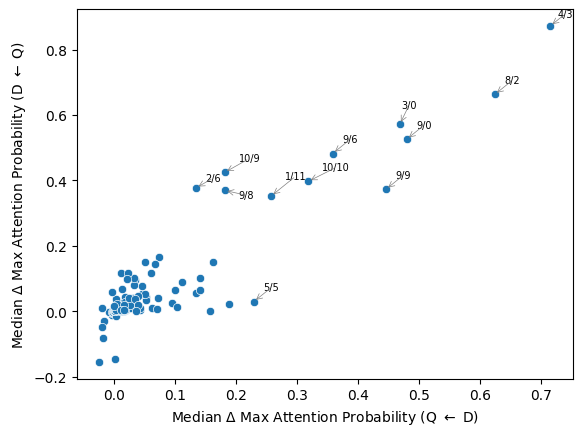

In [15]:
medians.sort_values("q2d_delta_weak", ascending=False).head(20)

default_label_kwargs = {
    'fontsize': 7,
    'color': 'black',
    # 'fontweight': 'bold'
}
# default_label_kwargs.update(label_kwargs)


p1 = sns.scatterplot(medians, x="q2d_delta_weak", y="d2q_delta_weak")
texts = []
for point in medians.itertuples():
    if (point.q2d_delta_weak > 0.2) or (point.d2q_delta_weak > 0.2):
        text = plt.text(point.q2d_delta_weak, point.d2q_delta_weak, f"{point.layer}/{point.head}", ha="left", va="bottom", **default_label_kwargs)
        texts.append(text)

if texts:
    adjust_text(texts, force_explode=2, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5), expand_points=(2, 2))


p1.xaxis.set_label_text(r'Median $\Delta$ Max Attention Probability (Q $\leftarrow$ D)');
p1.yaxis.set_label_text(r'Median $\Delta$ Max Attention Probability (D $\leftarrow$ Q)');

Text(13.000000000000002, 0.5, '$\\Delta$ Max Attention (D$\\leftarrow$Q)')

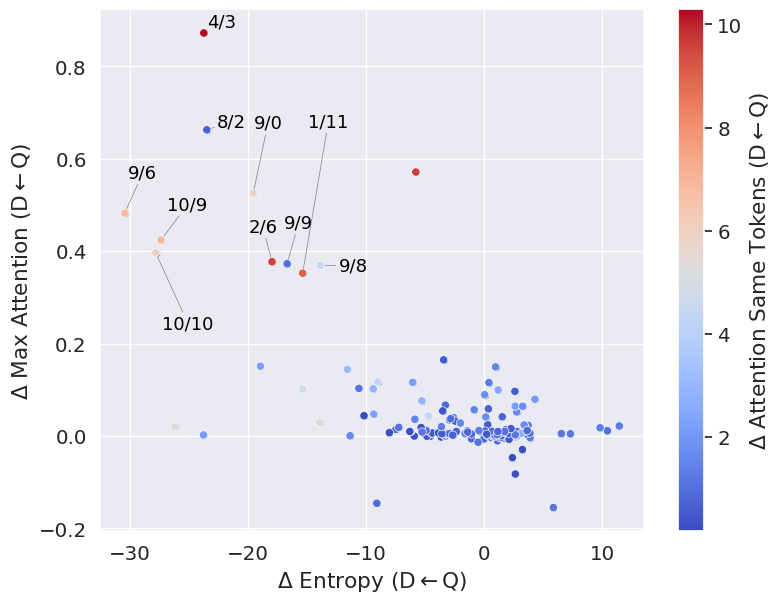

In [16]:
sns.set(font_scale=1.3)

default_label_kwargs = {
    'fontsize': 13,
    'color': 'black',
    # 'fontweight': 'bold'
}
# default_label_kwargs.update(label_kwargs)

p1 = sns.scatterplot(medians, x="ent_d2q_delta_weak", y="d2q_delta_weak")
texts = []
for point in medians.itertuples():
    if (point.ent_d2q_delta_weak < -7.5) and (point.d2q_delta_weak > 0.2):
        text = plt.text(point.ent_d2q_delta_weak, point.d2q_delta_weak, f"{point.layer}/{point.head}", ha="left", va="bottom", **default_label_kwargs)
        texts.append(text)

if texts:
    adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5), expand=(1.1, 3.7))

norm = plt.Normalize(medians["dup_d2q_delta_weak"].min(), medians["dup_d2q_delta_weak"].max())
sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=norm)
sm.set_array([])

plt.subplots_adjust(left=0.1, right=0.95, top=0.97, bottom=0.1)
p1 = sns.scatterplot(medians, x="ent_d2q_delta_weak", y="d2q_delta_weak", hue="dup_d2q_delta_weak", palette="coolwarm", legend=None)
plt.colorbar(sm, ax=plt.gca(), label=r'$\Delta$ Attention Same Tokens (D$\leftarrow$Q)')
plt.gcf().set_size_inches(8, 6)
p1.xaxis.set_label_text(r'$\Delta$ Entropy (D$\leftarrow$Q)')
p1.yaxis.set_label_text(r'$\Delta$ Max Attention (D$\leftarrow$Q)')

In [17]:
layers = list(int(x) for x in data_by_query["head"].unique())
layers.sort()
n_layers = len(data_by_query.layer.unique())

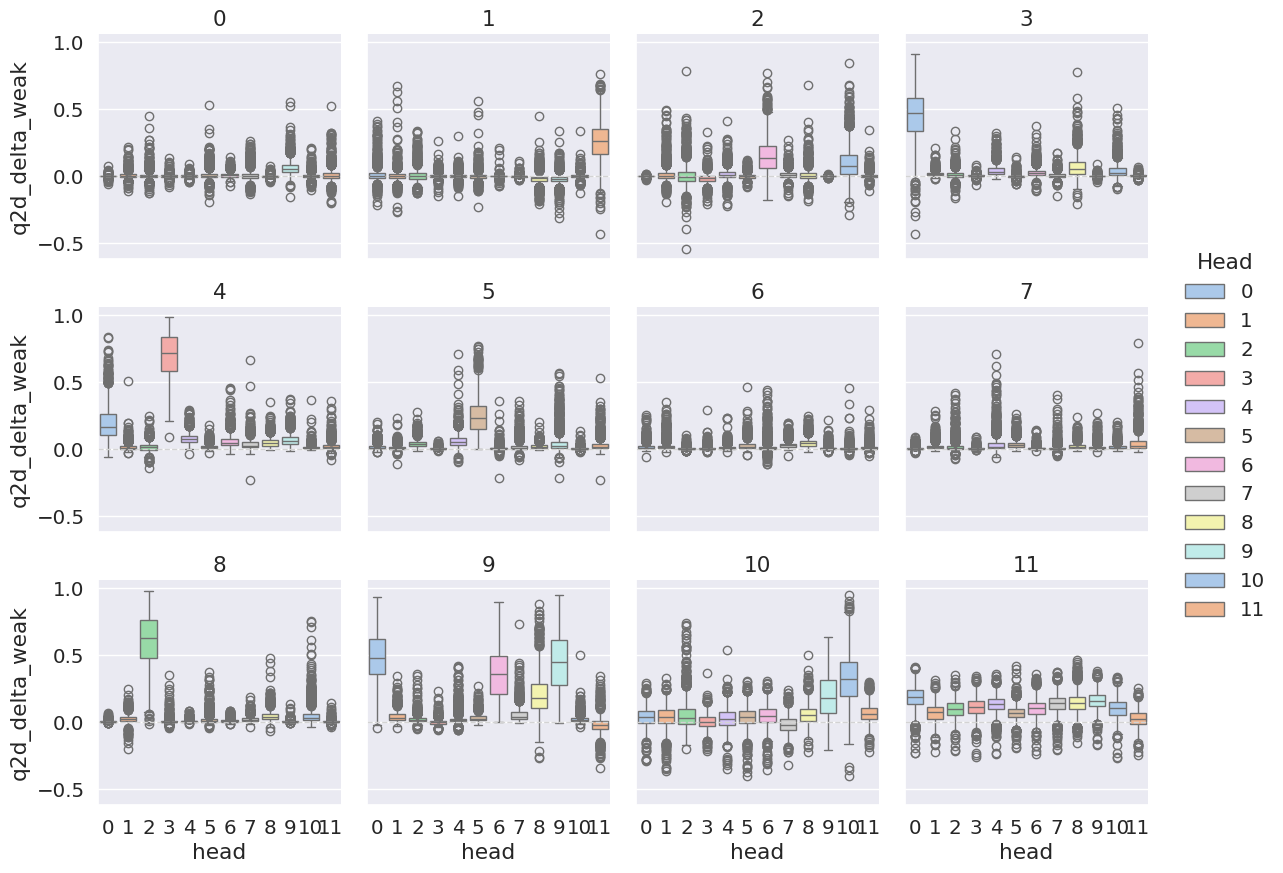

In [18]:
g = sns.FacetGrid(data=data_by_query, col="layer", col_wrap=4, height=n_layers/4, aspect=1)

# g.map(sns.boxplot, "head", "delta_weak", order=layers)
palette = "pastel"

def custom_boxplot(data, **kwargs):
    sns.boxplot(data=data, x="head", y="q2d_delta_weak", hue="head", palette=palette, dodge=False, **kwargs)
    plt.axhline(0, color="lightgray", linestyle="--", linewidth=1)  # Add a light gray line at y=0

g.map_dataframe(custom_boxplot)

# Adjust layout
g.add_legend(title="Head")

# Adjust layout
g.set_titles("{col_name}")
g.tight_layout()
plt.show()

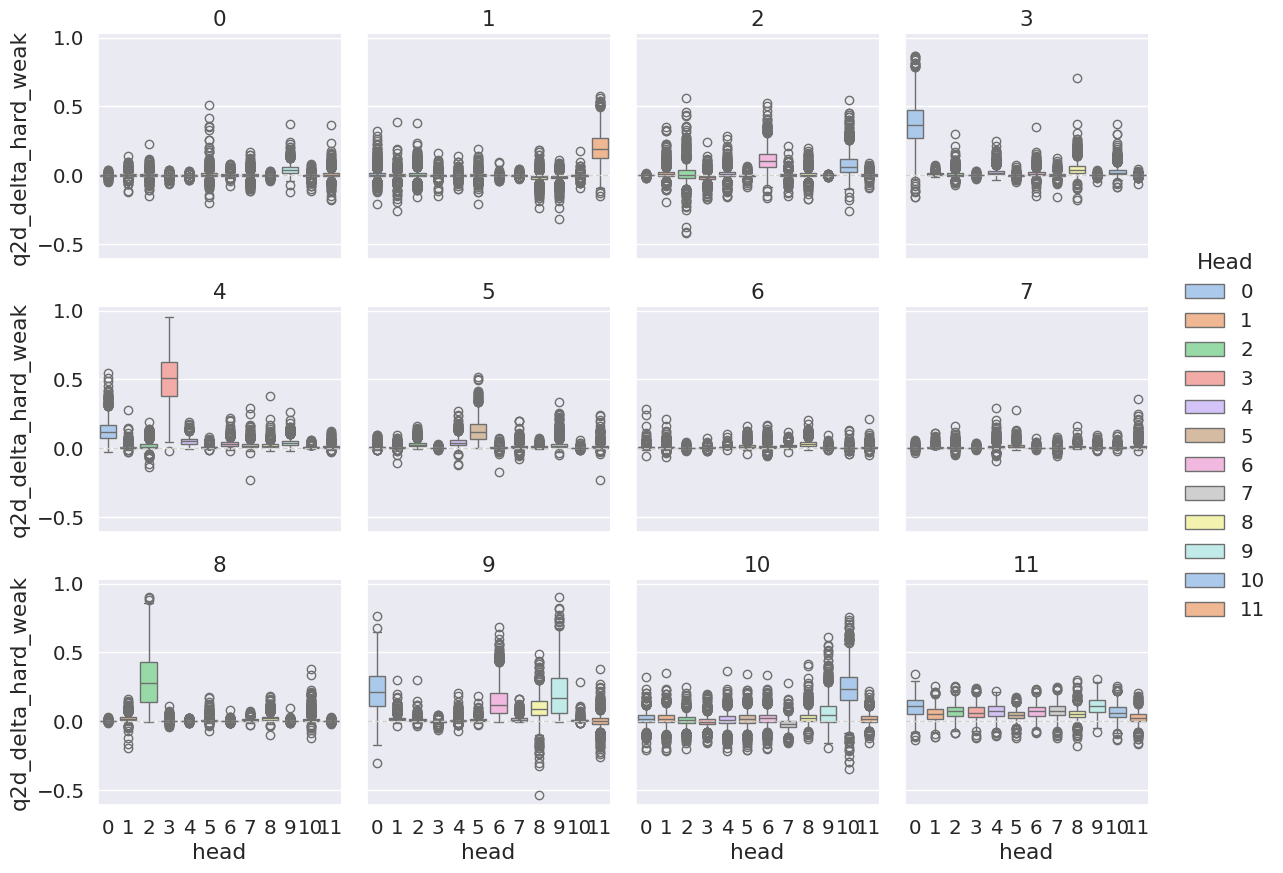

In [19]:
g = sns.FacetGrid(data=data_by_query, col="layer", col_wrap=4, height=n_layers/4, aspect=1)

# g.map(sns.boxplot, "head", "delta_weak", order=layers)
palette = "pastel"

def custom_boxplot(data, **kwargs):
    sns.boxplot(data=data, x="head", y="q2d_delta_hard_weak", hue="head", palette=palette, dodge=False, **kwargs)
    plt.axhline(0, color="lightgray", linestyle="--", linewidth=1)  # Add a light gray line at y=0

g.map_dataframe(custom_boxplot)

# Adjust layout
g.add_legend(title="Head")

# Adjust layout
g.set_titles("{col_name}")
g.tight_layout()
plt.show()

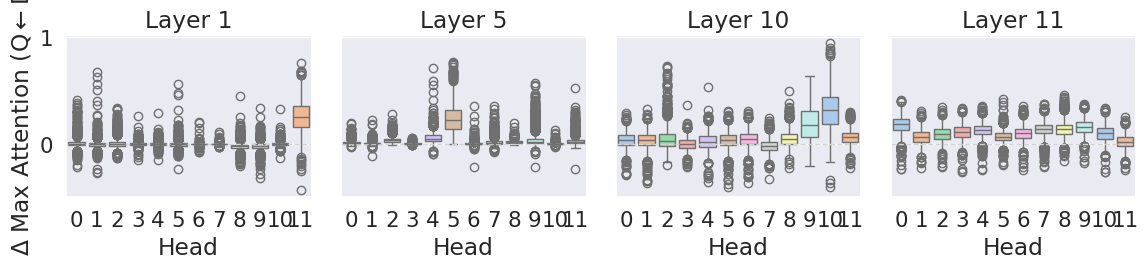

In [20]:
sns.set(font_scale=1.4)

data = data_by_query[data_by_query.layer.isin([1,5,10,11])]

g = sns.FacetGrid(data=data, col="layer", col_wrap=4, height=n_layers/4, aspect=1)

# g.map(sns.boxplot, "head", "delta_weak", order=layers)
palette = "pastel"

def custom_boxplot(data, **kwargs):
    sns.boxplot(data=data, x="head", y="q2d_delta_weak", hue="head", palette=palette, dodge=False, **kwargs)
    plt.axhline(0, color="lightgray", linestyle="--", linewidth=1)  # Add a light gray line at y=0

g.map_dataframe(custom_boxplot)

# Adjust layout
# g.add_legend(title="Head")

# Adjust layout
g.set_titles("Layer {col_name}")
#g.tight_layout()
g.set_axis_labels(r'Head', r'$\Delta$ Max Attention (Q$\leftarrow$D)')

plt.show()